# FASE 2 - Paso 1: Análisis Exploratorio de Sarcasmo

**Objetivo**: Descargar dataset de Sarcasmo desde HuggingFace, crear splits, visualizar distribución y analizar características.

**Dataset**: Sarcasm Detection Dataset (Español)
- **Fuente**: HuggingFace Datasets
- **Clases**: SARCASMO, NO_SARCASMO (clasificación binaria)
- **Tarea**: Detección de sarcasmo en textos en español

**✅ Este notebook se ejecuta LOCAL (sin GPU)**

---

## 1. Importar Librerías

In [3]:
# Librerías estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# HuggingFace Datasets
from datasets import load_dataset

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Descargar Dataset desde HuggingFace

**Nota**: El dataset de Sarcasmo se descarga directamente desde HuggingFace.

**Dataset**: `Ernesto-1997/Sarcastic_spanish_dataset`

In [4]:
# Descargar dataset de sarcasmo desde HuggingFace
print("📥 Descargando dataset de Sarcasmo desde HuggingFace...")
print("="*70)

# Cargar dataset: Ernesto-1997/Sarcastic_spanish_dataset
dataset = load_dataset("Ernesto-1997/Sarcastic_spanish_dataset")
print(f"✅ Dataset cargado desde: Ernesto-1997/Sarcastic_spanish_dataset")

print(f"\n📊 Estructura del dataset:")
print(dataset)
print("="*70)

📥 Descargando dataset de Sarcasmo desde HuggingFace...


Generating validation split: 100%|██████████| 3820/3820 [00:00<00:00, 236973.34 examples/s]

✅ Dataset cargado desde: Ernesto-1997/Sarcastic_spanish_dataset

📊 Estructura del dataset:
DatasetDict({
    train: Dataset({
        features: ['Texto', 'Sarcasmo'],
        num_rows: 15276
    })
    validation: Dataset({
        features: ['Texto', 'Sarcasmo'],
        num_rows: 3820
    })
})


## 3. Convertir a Pandas y Explorar

In [5]:
# Convertir a pandas para análisis
if 'train' in dataset:
    df_train_full = pd.DataFrame(dataset['train'])
else:
    # Si no hay split train/test, usar todo el dataset
    df_train_full = pd.DataFrame(dataset)

# Verificar si existe test split
if 'test' in dataset:
    df_test = pd.DataFrame(dataset['test'])
else:
    df_test = None

print(f"\n📊 Tamaño del dataset:")
print(f"   - Train completo: {len(df_train_full)} muestras")
if df_test is not None:
    print(f"   - Test: {len(df_test)} muestras")
    print(f"   - TOTAL: {len(df_train_full) + len(df_test)} muestras")

print(f"\n📋 Columnas del dataset:")
print(df_train_full.columns.tolist())

print(f"\n👀 Primeras 5 muestras:")
df_train_full.head()


📊 Tamaño del dataset:
   - Train completo: 15276 muestras

📋 Columnas del dataset:
['Texto', 'Sarcasmo']

👀 Primeras 5 muestras:


,Texto,Sarcasmo
0,Así son las grabaciones que comprometen a Fern...,1
1,Clan TV no sabe cómo preparar a los niños para...,1
2,Muelas de elefante y casuarios: así aprenden e...,0
3,"Qué bien, las discusiones solo fortalecen la r...",1
4,Clásicos en Alcalá dedica este año a Cervantes...,0


## 4. Detección Automática de Columnas

Detectar automáticamente columnas de texto y etiquetas.

In [6]:
# Detectar columna de texto (la que tenga más caracteres en promedio)
def detect_text_column(df):
    candidates = []
    for col in df.columns:
        if df[col].dtype == 'object':  # Solo columnas de texto
            avg_length = df[col].astype(str).str.len().mean()
            if avg_length > 20:  # Probablemente sea texto largo
                candidates.append((col, avg_length))
    
    if candidates:
        # La columna con mayor longitud promedio es probablemente el texto
        text_col = max(candidates, key=lambda x: x[1])[0]
        return text_col
    return None

# Detectar columna de etiqueta (la que tenga menos valores únicos)
def detect_label_column(df, exclude_col=None):
    candidates = []
    for col in df.columns:
        if col != exclude_col:
            unique_count = df[col].nunique()
            if 2 <= unique_count <= 5:  # Entre 2 y 5 clases
                candidates.append((col, unique_count))
    
    if candidates:
        # La columna con menos valores únicos es probablemente la etiqueta
        label_col = min(candidates, key=lambda x: x[1])[0]
        return label_col
    return None

# Detectar columnas
TEXT_COL = detect_text_column(df_train_full)
LABEL_COL = detect_label_column(df_train_full, exclude_col=TEXT_COL)

print(f"\n🔍 Columnas detectadas:")
print(f"   - Texto: '{TEXT_COL}'")
print(f"   - Etiqueta: '{LABEL_COL}'")

# Verificar detección
if TEXT_COL is None or LABEL_COL is None:
    print("\n⚠️ No se pudieron detectar las columnas automáticamente.")
    print("   Por favor, ajusta manualmente TEXT_COL y LABEL_COL en la siguiente celda.")
else:
    print(f"\n✅ Detección exitosa")


🔍 Columnas detectadas:
   - Texto: 'Texto'
   - Etiqueta: 'Sarcasmo'

✅ Detección exitosa


In [7]:
# Si la detección automática falló, ajustar manualmente aquí:
# TEXT_COL = 'text'  # Ajustar nombre correcto
# LABEL_COL = 'label'  # Ajustar nombre correcto

print(f"📌 Columnas finales:")
print(f"   - Texto: '{TEXT_COL}'")
print(f"   - Etiqueta: '{LABEL_COL}'")

# Verificar clases
classes = sorted(df_train_full[LABEL_COL].unique())
print(f"\n🏷️ Clases encontradas: {classes}")
print(f"   - Número de clases: {len(classes)}")

📌 Columnas finales:
   - Texto: 'Texto'
   - Etiqueta: 'Sarcasmo'

🏷️ Clases encontradas: [np.int64(0), np.int64(1)]
   - Número de clases: 2


## 5. Crear Splits (Train/Validation/Test)

Si el dataset no tiene split de test, crear uno. También crear validation set.

In [8]:
from sklearn.model_selection import train_test_split

# Si ya existe test split, usarlo
if df_test is not None:
    print("✅ Dataset ya tiene split de test")
    # Crear validation del train
    df_train, df_val = train_test_split(
        df_train_full, 
        test_size=0.2, 
        random_state=42, 
        stratify=df_train_full[LABEL_COL]
    )
else:
    print("⚠️ Dataset no tiene split de test, creando splits...")
    # Crear train/val/test: 70/15/15
    df_train, df_temp = train_test_split(
        df_train_full, 
        test_size=0.3, 
        random_state=42, 
        stratify=df_train_full[LABEL_COL]
    )
    df_val, df_test = train_test_split(
        df_temp, 
        test_size=0.5, 
        random_state=42, 
        stratify=df_temp[LABEL_COL]
    )

print(f"\n📊 Splits creados:")
print(f"   - Train: {len(df_train)} muestras")
print(f"   - Validation: {len(df_val)} muestras")
print(f"   - Test: {len(df_test)} muestras")
print(f"   - TOTAL: {len(df_train) + len(df_val) + len(df_test)} muestras")

⚠️ Dataset no tiene split de test, creando splits...

📊 Splits creados:
   - Train: 10693 muestras
   - Validation: 2291 muestras
   - Test: 2292 muestras
   - TOTAL: 15276 muestras


## 6. Análisis de Distribución de Clases

In [9]:
# Análisis de distribución
print("\n📊 DISTRIBUCIÓN DE CLASES")
print("="*70)

print("\n🔹 Train:")
train_dist = df_train[LABEL_COL].value_counts()
for label, count in train_dist.items():
    percentage = (count / len(df_train)) * 100
    print(f"   {label:>15}: {count:>6} ({percentage:>5.2f}%)")

print("\n🔹 Validation:")
val_dist = df_val[LABEL_COL].value_counts()
for label, count in val_dist.items():
    percentage = (count / len(df_val)) * 100
    print(f"   {label:>15}: {count:>6} ({percentage:>5.2f}%)")

print("\n🔹 Test:")
test_dist = df_test[LABEL_COL].value_counts()
for label, count in test_dist.items():
    percentage = (count / len(df_test)) * 100
    print(f"   {label:>15}: {count:>6} ({percentage:>5.2f}%)")

# Calcular desbalanceo
max_count = train_dist.max()
min_count = train_dist.min()
imbalance_ratio = max_count / min_count

print(f"\n📈 Ratio de desbalanceo: {imbalance_ratio:.2f}x")
if imbalance_ratio < 1.5:
    print("   ✅ Dataset balanceado (no requiere técnicas de balanceo)")
elif imbalance_ratio < 3:
    print("   ⚠️ Desbalanceo moderado (considerar class_weight)")
else:
    print("   ❌ Desbalanceo severo (requiere oversampling/undersampling)")

print("="*70)


📊 DISTRIBUCIÓN DE CLASES

🔹 Train:
                 0:   6413 (59.97%)
                 1:   4280 (40.03%)

🔹 Validation:
                 0:   1374 (59.97%)
                 1:    917 (40.03%)

🔹 Test:
                 0:   1375 (59.99%)
                 1:    917 (40.01%)

📈 Ratio de desbalanceo: 1.50x
   ✅ Dataset balanceado (no requiere técnicas de balanceo)


## 7. Visualización de Distribución

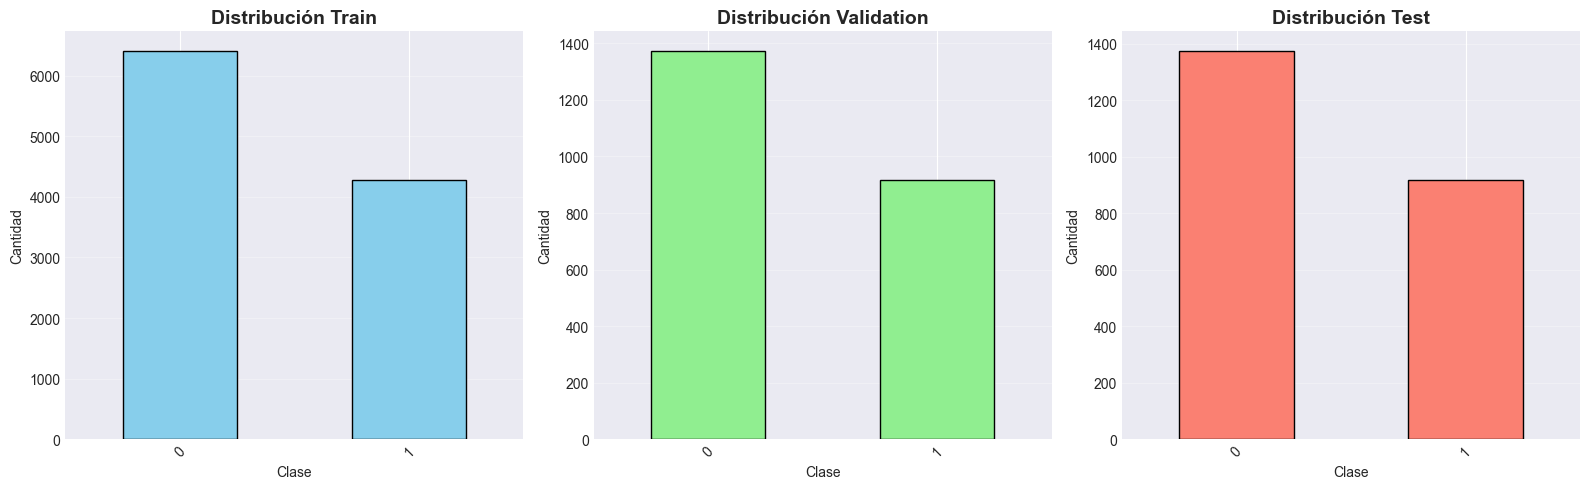


💾 Gráfico guardado: resultados/fase2_sarcasmo/distribucion_clases_Sarcasmo.png


In [10]:
# Crear gráfico de distribución
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Train
train_dist.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribución Train', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Validation
val_dist.plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Distribución Validation', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Test
test_dist.plot(kind='bar', ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Distribución Test', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Clase')
axes[2].set_ylabel('Cantidad')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../resultados/fase2_sarcasmo/distribucion_clases_Sarcasmo.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Gráfico guardado: resultados/fase2_sarcasmo/distribucion_clases_Sarcasmo.png")

## 8. Análisis de Longitud de Textos

In [11]:
# Calcular longitudes
df_train['len_chars'] = df_train[TEXT_COL].astype(str).str.len()
df_train['len_words'] = df_train[TEXT_COL].astype(str).str.split().str.len()

df_val['len_chars'] = df_val[TEXT_COL].astype(str).str.len()
df_val['len_words'] = df_val[TEXT_COL].astype(str).str.split().str.len()

df_test['len_chars'] = df_test[TEXT_COL].astype(str).str.len()
df_test['len_words'] = df_test[TEXT_COL].astype(str).str.split().str.len()

print("\n📏 ESTADÍSTICAS DE LONGITUD")
print("="*70)

print("\n🔹 Caracteres:")
print(f"   Media: {df_train['len_chars'].mean():.2f}")
print(f"   Mediana: {df_train['len_chars'].median():.0f}")
print(f"   Min: {df_train['len_chars'].min()}")
print(f"   Max: {df_train['len_chars'].max()}")
print(f"   Percentil 95: {df_train['len_chars'].quantile(0.95):.0f}")

print("\n🔹 Palabras:")
print(f"   Media: {df_train['len_words'].mean():.2f}")
print(f"   Mediana: {df_train['len_words'].median():.0f}")
print(f"   Min: {df_train['len_words'].min()}")
print(f"   Max: {df_train['len_words'].max()}")
print(f"   Percentil 95: {df_train['len_words'].quantile(0.95):.0f}")

# Recomendación para max_length
p95_words = df_train['len_words'].quantile(0.95)
recommended_max_length = int(np.ceil(p95_words * 1.5))  # 1.5x por subwords
recommended_max_length = min(recommended_max_length, 128)  # No más de 128

print(f"\n💡 Recomendación para tokenización:")
print(f"   max_length = {recommended_max_length} tokens (cubre >95% de textos)")
print("="*70)


📏 ESTADÍSTICAS DE LONGITUD

🔹 Caracteres:
   Media: 71.84
   Mediana: 72
   Min: 2
   Max: 1224
   Percentil 95: 119

🔹 Palabras:
   Media: 12.41
   Mediana: 12
   Min: 1
   Max: 217
   Percentil 95: 21

💡 Recomendación para tokenización:
   max_length = 32 tokens (cubre >95% de textos)


## 9. Visualización de Longitudes

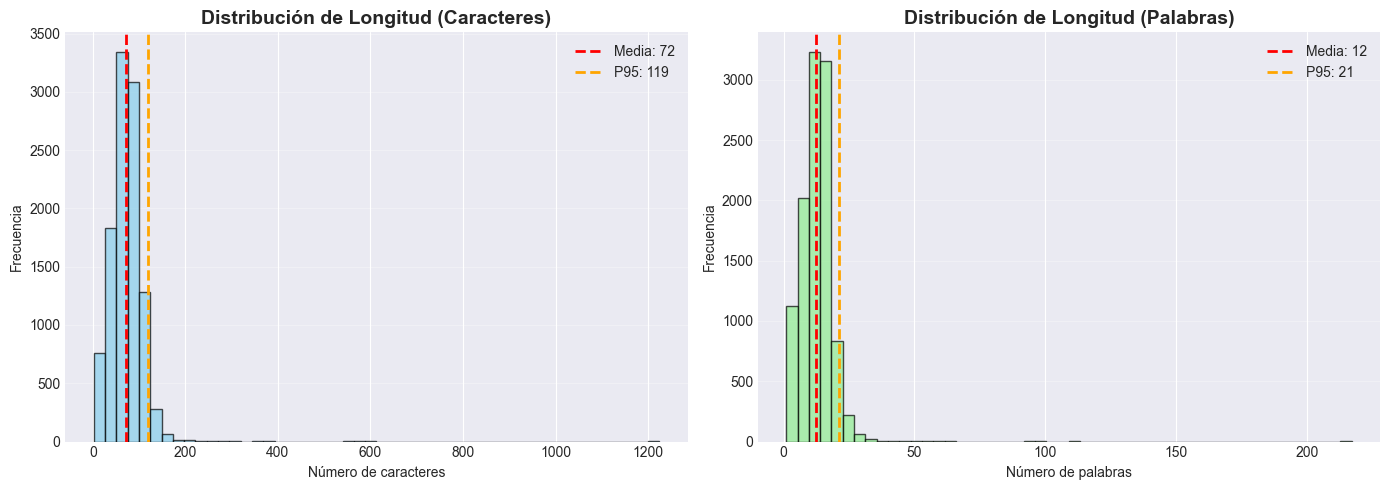


💾 Gráfico guardado: resultados/fase2_sarcasmo/distribucion_longitudes_Sarcasmo.png


In [12]:
# Histogramas de longitud
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Caracteres
axes[0].hist(df_train['len_chars'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_train['len_chars'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df_train["len_chars"].mean():.0f}')
axes[0].axvline(df_train['len_chars'].quantile(0.95), color='orange', linestyle='--', linewidth=2, label=f'P95: {df_train["len_chars"].quantile(0.95):.0f}')
axes[0].set_title('Distribución de Longitud (Caracteres)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Número de caracteres')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Palabras
axes[1].hist(df_train['len_words'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(df_train['len_words'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df_train["len_words"].mean():.0f}')
axes[1].axvline(df_train['len_words'].quantile(0.95), color='orange', linestyle='--', linewidth=2, label=f'P95: {df_train["len_words"].quantile(0.95):.0f}')
axes[1].set_title('Distribución de Longitud (Palabras)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../resultados/fase2_sarcasmo/distribucion_longitudes_Sarcasmo.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Gráfico guardado: resultados/fase2_sarcasmo/distribucion_longitudes_Sarcasmo.png")

## 10. Longitud por Clase

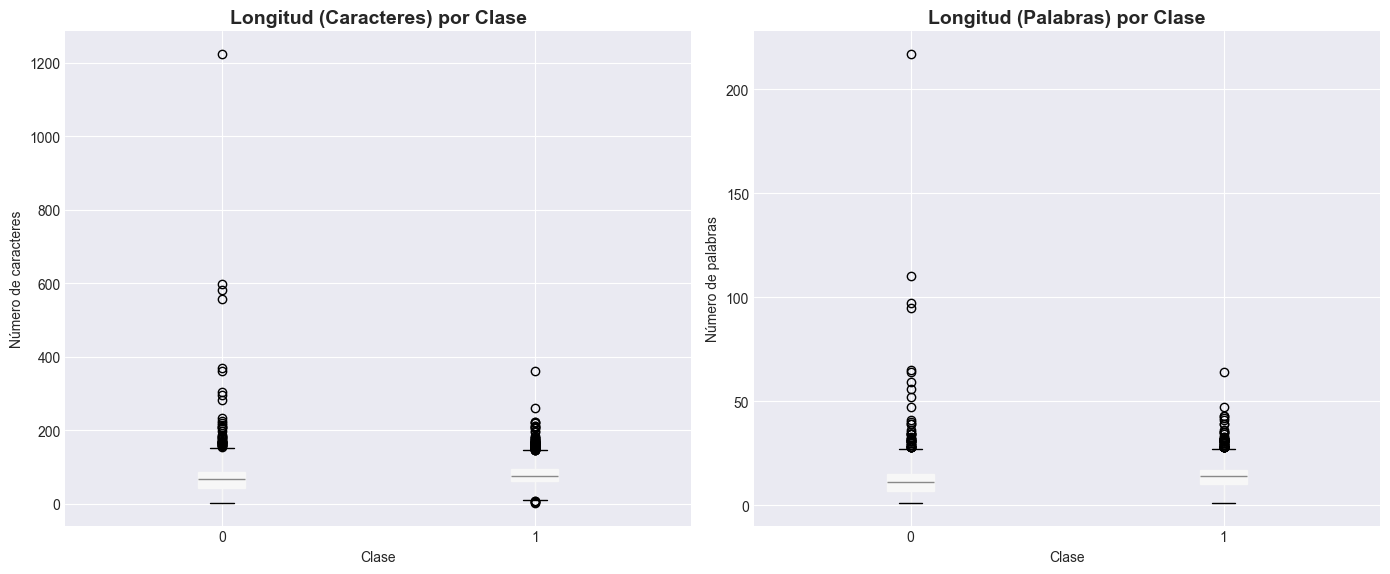


💾 Gráfico guardado: resultados/fase2_sarcasmo/longitud_por_clase_Sarcasmo.png


In [13]:
# Boxplot de longitud por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Caracteres por clase
df_train.boxplot(column='len_chars', by=LABEL_COL, ax=axes[0], patch_artist=True)
axes[0].set_title('Longitud (Caracteres) por Clase', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Número de caracteres')
axes[0].get_figure().suptitle('')  # Remover título automático

# Palabras por clase
df_train.boxplot(column='len_words', by=LABEL_COL, ax=axes[1], patch_artist=True)
axes[1].set_title('Longitud (Palabras) por Clase', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Número de palabras')
axes[1].get_figure().suptitle('')  # Remover título automático

plt.tight_layout()
plt.savefig('../resultados/fase2_sarcasmo/longitud_por_clase_Sarcasmo.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Gráfico guardado: resultados/fase2_sarcasmo/longitud_por_clase_Sarcasmo.png")

## 11. Guardar Datasets Procesados

In [14]:
# Crear carpeta de resultados si no existe
import os
os.makedirs('../resultados/fase2_sarcasmo', exist_ok=True)

# Guardar datasets
df_train.to_csv('../resultados/fase2_sarcasmo/sarcasmo_train.csv', index=False)
df_val.to_csv('../resultados/fase2_sarcasmo/sarcasmo_validation.csv', index=False)
df_test.to_csv('../resultados/fase2_sarcasmo/sarcasmo_test.csv', index=False)

print("\n💾 Datasets guardados en: resultados/fase2_sarcasmo/")
print(f"   - sarcasmo_train.csv ({len(df_train)} muestras)")
print(f"   - sarcasmo_validation.csv ({len(df_val)} muestras)")
print(f"   - sarcasmo_test.csv ({len(df_test)} muestras)")
print(f"\n✅ Total: {len(df_train) + len(df_val) + len(df_test)} muestras guardadas")


💾 Datasets guardados en: resultados/fase2_sarcasmo/
   - sarcasmo_train.csv (10693 muestras)
   - sarcasmo_validation.csv (2291 muestras)
   - sarcasmo_test.csv (2292 muestras)

✅ Total: 15276 muestras guardadas


## 12. Resumen y Próximos Pasos

In [16]:
print("\n" + "="*70)
print("📊 RESUMEN DEL ANÁLISIS EXPLORATORIO - SARCASMO")
print("="*70)

print(f"\n✅ Dataset procesado correctamente:")
print(f"   - Train: {len(df_train)} muestras")
print(f"   - Validation: {len(df_val)} muestras")
print(f"   - Test: {len(df_test)} muestras")
print(f"   - TOTAL: {len(df_train) + len(df_val) + len(df_test)} muestras")

print(f"\n✅ Distribución de clases: {len(classes)} clases")
for label in classes:
    count = len(df_train[df_train[LABEL_COL] == label])
    percentage = (count / len(df_train)) * 100
    print(f"   - {label}: {count} ({percentage:.2f}%)")

print(f"\n✅ Características de textos:")
print(f"   - Media: {df_train['len_words'].mean():.2f} palabras")
print(f"   - Recomendación: max_length={recommended_max_length} tokens")

print(f"\n✅ Archivos generados:")
print(f"   - 3 CSVs (train/val/test)")
print(f"   - 3 gráficos PNG (distribución + longitudes)")




📊 RESUMEN DEL ANÁLISIS EXPLORATORIO - SARCASMO

✅ Dataset procesado correctamente:
   - Train: 10693 muestras
   - Validation: 2291 muestras
   - Test: 2292 muestras
   - TOTAL: 15276 muestras

✅ Distribución de clases: 2 clases
   - 0: 6413 (59.97%)
   - 1: 4280 (40.03%)

✅ Características de textos:
   - Media: 12.41 palabras
   - Recomendación: max_length=32 tokens

✅ Archivos generados:
   - 3 CSVs (train/val/test)
   - 3 gráficos PNG (distribución + longitudes)
